# Ye & Ghassemi (2018) SWT2 - numerical results versus validation

This notebook compares all available `SWT2/results_csv` time histories with the digitized `SWT2` validation curves stored in `SWT2/SWT2`.


In [37]:
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 8,
})

SAMPLE = 'SWT2'
cwd = Path.cwd().resolve()
SEARCH_ROOTS = [cwd, *cwd.parents]
BASE_CANDIDATES = SEARCH_ROOTS + [
    root / 'Examples' / 'YeGhasemmi2018' / SAMPLE for root in SEARCH_ROOTS
]
seen = set()
BASE_CANDIDATES = [
    path for path in BASE_CANDIDATES
    if not (str(path) in seen or seen.add(str(path)))
]
BASE = next(
    (
        path for path in BASE_CANDIDATES
        if path.name == SAMPLE
        and (path / SAMPLE).is_dir()
        and (path / 'results_csv').is_dir()
    ),
    None,
)
if BASE is None:
    searched = '\n'.join(str(path) for path in BASE_CANDIDATES)
    raise FileNotFoundError(
        f'Could not locate the {SAMPLE} folder containing {SAMPLE}/ validation data '
        f'and results_csv/. Searched:\n{searched}'
    )

VALID = BASE / SAMPLE
RESULTS = BASE / 'results_csv'
HPC_RESULTS = BASE / 'results_csv_hpc_rorqual'
RESULT_DIRS = [RESULTS, HPC_RESULTS]
END_TIME_TOLERANCE_S = 1.0


def has_time_column(path):
    try:
        return 'time' in pd.read_csv(path, nrows=0).columns
    except Exception as exc:
        warnings.warn(f'Could not inspect {path}: {exc}')
        return False


input_decks = sorted(BASE.glob('*.i'))


# Manual plotting selection. Only uncommented entries in this dictionary can be loaded.
# Comment out a complete entry to hide that case; CSV files are never added automatically.
# Uncomment an entry to include it when its CSV is available.
cases = {
    # 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe.i',
    #     'style': '-.',
    #     'color': 'tab:blue',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # run locally
    # # ran on 8 cores
    # # took 21186.66 seconds
    # 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV.i',
    #     'style': '-',
    #     'color': 'tab:red',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_biot0p6': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_biot0p6.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_biot0p6.i',
    #     'style': '--',
    #     'color': 'tab:green',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_biot0p6_mesh3': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_biot0p6_mesh3.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_biot0p6_mesh3.i',
    #     'style': ':',
    #     'color': 'tab:orange',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_mesh3': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_mesh3.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_21_F0p90_Pp0p60_T40p20_U0p84_A0p0165_BBhyd_IOsafe_kernel_SV_mesh3.i',
    #     'style': '-.',
    #     'color': 'tab:purple',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe.i',
    #     'style': '-',
    #     'color': 'tab:brown',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe_kernel_SV': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe_kernel_SV.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe_kernel_SV.i',
    #     'style': '--',
    #     'color': 'tab:pink',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe_kernel_SV_mesh3': {
    #     'csv': RESULTS / 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe_kernel_SV_mesh3.csv',
    #     'input': BASE / 'Ye2018_SWT2_BBFast_sweep_22_F0p90_Pp0p55_T40p20_U0p84_A0p0165_BBhyd_Timing_IOsafe_kernel_SV_mesh3.i',
    #     'style': ':',
    #     'color': 'tab:gray',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # '89_03_swt2_bbfast_theta30_kernel_SV_biot0p6_hpc': {
    #     'csv': HPC_RESULTS / '89_03_swt2_bbfast_theta30_kernel_SV_biot0p6_hpc.csv',
    #     'input': BASE / '89_03_swt2_bbfast_theta30_kernel_SV_biot0p6.i',
    #     'style': '-.',
    #     'color': 'tab:olive',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # '89_05_swt2_bbfast_theta30_cohesion_kernel_SV_biot0p6_hpc': {
    #     'csv': HPC_RESULTS / '89_05_swt2_bbfast_theta30_cohesion_kernel_SV_biot0p6_hpc.csv',
    #     'input': BASE / '89_05_swt2_bbfast_theta30_cohesion_kernel_SV_biot0p6.i',
    #     'style': '-',
    #     'color': 'tab:cyan',
    #     'kind': 'simulation',
    #     'required': True,
    # },
    # run on Rorqual
    # ran on 32 CPU cores
    '90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc': {
        'csv': HPC_RESULTS / '90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc.csv',
        'input': BASE / '90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6.i',
        'style': ':',
        'color': 'tab:blue',
        'kind': 'simulation',
        'required': True,
    },
    # # run on Rorqual
    # # ran on 32 CPU cores
    # # this one is completely worng
    # '90_04_swt2_bbfast_theta30_cohesion_c35p0_kernel_SV_biot0p6_hpc': {
    #     'csv': HPC_RESULTS / '90_04_swt2_bbfast_theta30_cohesion_c35p0_kernel_SV_biot0p6_hpc.csv',
    #     'input': BASE / '90_04_swt2_bbfast_theta30_cohesion_c35p0_kernel_SV_biot0p6.i',
    #     'style': '--',
    #     'color': 'tab:purple',
    #     'kind': 'simulation',
    #     'required': True,
    # },

    # run on Rorqual
    # ran on 32 CPU cores
    '91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc': {
        'csv': HPC_RESULTS / '91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc.csv',
        'input': BASE / '91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc.i',
        'style': ':',
        'color': 'tab:cyan',
        'kind': 'simulation',
        'required': True,
    },
    # run on Rorqual
    # ran on 32 CPU cores
    '91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc': {
        'csv': HPC_RESULTS / '91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc.csv',
        'input': BASE / '91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc.i',
        'style': '--',
        'color': 'tab:purple',
        'kind': 'simulation',
        'required': True,
    },
}

selected_cases = dict(cases)
if not selected_cases:
    raise ValueError('No plotting cases are selected. Uncomment at least one dictionary entry.')

cases = {
    name: cfg
    for name, cfg in selected_cases.items()
    if cfg['csv'].is_file() and has_time_column(cfg['csv'])
}

if not cases:
    raise FileNotFoundError(
        'None of the uncommented plotting cases has an available time-series CSV.'
    )

print(f'Sample folder: {BASE}')
print(f'Validation folder: {VALID}')
print(f'Found {len(input_decks)} input deck(s).')
print(f'Plotting {len(cases)} available case(s) selected by the manual dictionary.')
for name, cfg in cases.items():
    input_status = cfg['input'].name if cfg['input'].exists() else 'no matching input deck'
    print(f'{name}: {cfg["csv"].name}; input = {input_status}')


Sample folder: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWT2
Validation folder: /media/geomechanics/Data4TB/projects/orca_4.0/Examples/YeGhasemmi2018/SWT2/SWT2
Found 15 input deck(s).
Plotting 3 available case(s) selected by the manual dictionary.
90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc: 90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc.csv; input = 90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6.i
91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc: 91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc.csv; input = no matching input deck
91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc: 91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc.csv; input = no matching input deck


In [38]:
def load_digitized(name):
    path = VALID / name
    if not path.exists():
        warnings.warn(f'Missing validation file: {path}')
        return pd.DataFrame(columns=['time_s', 'value'])
    df = pd.read_csv(path, header=None, names=['time_s', 'value'])
    df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna().sort_values('time_s').reset_index(drop=True)


VALIDATION_FILES = {
    "differential_stress": "SWt2_differential_stress.csv",
    "injection_pressure": "SWT2_injection_pressure_MPA.csv",
    "flow_rate": "SWt2_flow_rate_ml:min.csv",
    "frac_perm": "SWt2_fracture_peremabiltiy_m2.csv",
    "normal_dilation": "SWT2_normal_dilation_mm.csv",
    "normal_stress": "SWT2_effective_normal_stress_MPa.csv",
    "shear_slip": "SWt2_shear_dilation_mm.csv",
    "shear_stress": "SWT2_shear_stress_MPa.csv"
}
validation = {key: load_digitized(filename) for key, filename in VALIDATION_FILES.items()}
missing_validation = [filename for key, filename in VALIDATION_FILES.items() if validation[key].empty]
if missing_validation:
    searched = '\n'.join(str(VALID / filename) for filename in missing_validation)
    raise FileNotFoundError(
        f'Missing SWT2 digitized validation CSVs in {VALID}:\n{searched}'
    )

# Timing criteria are sample-specific. The end criterion comes directly from the
# latest digitized validation point; the event window brackets the major measured
# stress/slip/dilation transition for this sample.
VALIDATION_END_TIME_S = max(float(df['time_s'].max()) for df in validation.values())
DEFAULT_INTENDED_END_TIME_S = VALIDATION_END_TIME_S
EVENT_TIME_S = 2265.0
EVENT_WINDOW_S = (2100.0, 2425.0)
EVENT_BASELINE_END_S = EVENT_WINDOW_S[0]
VALIDATION_END_TOLERANCE_S = max(END_TIME_TOLERANCE_S, 0.01 * VALIDATION_END_TIME_S)

print(f'Validation time criterion: {VALIDATION_END_TIME_S:.3f} s '
      f'(coverage tolerance {VALIDATION_END_TOLERANCE_S:.3f} s)')
print(f'Major validation-event window: {EVENT_WINDOW_S[0]:.1f}-{EVENT_WINDOW_S[1]:.1f} s')


Validation time criterion: 2830.000 s (coverage tolerance 28.300 s)
Major validation-event window: 2100.0-2425.0 s


In [39]:
COLUMN_ALIASES = {
    'time_s': [('time', 1.0)],
    # 2026-08-17 CHANNEL FIX: differential_stress_mpa_pp = (sigma1_pp - 30e6)*1e-6 subtracts a
    # TOTAL confining stress from a SKELETON axial stress, so it reads alpha*p (~3.5 MPa) low for
    # the whole run. The deck's own comment above it already warned it 'ASSUMES sigma3 = 30 MPa
    # exactly'. differential_stress_reaction_mpa_pp = |top reaction|/A - confining is the load-cell
    # measurement the paper reports, and it agrees with differential_stress_skeleton_bulk_pp
    # (sigma1 - sigma3_bulk) to <0.4 MPa. It is also the channel the paper-frame tau and sigma'_n
    # operators already consume, so this makes the plotted panel consistent with the scored margin.
    'differential_stress_mpa': [('differential_stress_reaction_mpa_pp', 1.0), ('differential_stress_skeleton_bulk_pp', 1.0), ('differential_stress_mpa_pp', 1.0), ('differential_stress_pp', 1.0e-6)],
    'injection_pressure_pa': [('injection_pressure_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    'interface_pore_pressure_pa': [('fracture_pressure_mean_pp', 1.0), ('fracture_pressure_mean_target_pp', 1.0), ('injection_pressure_pp', 1.0)],
    # NOTE: flow_rate_pp is a MASS flow rate (kg/s), not volumetric (m^3/s) -- the underlying
    # Darcy/storage kernels use multiply_by_fluid_density=true. The other candidates above are
    # already volumetric mL/min and take priority; flow_rate_pp is only the last-resort fallback,
    # so its scale must first divide out fluid_density_ref (~1000 kg/m^3) before applying the
    # m^3/s -> mL/min factor of 6.0e7, i.e. 6.0e7/1000 = 6.0e4. (Previously 6.0e7, which silently
    # over-reported by ~1000x whenever this fallback path was actually taken.)
    'flow_rate_ml_min': [('flow_rate_validation_ml_min_pp', 1.0), ('flow_rate_transmissivity_target_ml_min_pp', 1.0), ('flow_rate_cubic_target_ml_min_pp', 1.0), ('flow_rate_reaction_ml_min_pp', 1.0), ('flow_rate_pp', 6.0e4)],
    'fracture_permeability_m2': [('fracture_permeability_pp', 1.0)],
    'fracture_transmissivity_m3_pa_s': [('fracture_transmissivity_pp', 1.0)],
    'hydraulic_aperture_m': [('hydraulic_aperture_pp', 1.0)],
    'bb_normal_stress_pa': [('bb_normal_stress_pp', 1.0), ('czm_sigma_n_pp', 1.0)],
    'bb_effective_normal_stress_pa': [('bb_effective_normal_stress_pp', 1.0), ('effective_normal_stress_est_pp', 1.0), ('effective_normal_stress_mpa_pp', 1.0e6)],
    'bb_limit_tau_pa': [('bb_limit_tau_pp', 1.0)],
    'shear_stress_mpa': [('shear_stress_mpa_pp', 1.0), ('shear_stress_est_pp', 1.0e-6)],
    'normal_dilation_mm': [('fracture_normal_dilation_local_mm_pp', 1.0), ('normal_dilation_validation_mm_pp', 1.0), ('czm_normal_dilation_paper_mm_pp', 1.0), ('normal_displacement_raw_mm_pp', 1.0), ('dn_lvdt_paper_mm', 1.0)],
    'shear_slip_mm': [('fracture_shear_slip_local_mm_pp', 1.0), ('shear_slip_validation_mm_pp', 1.0), ('czm_shear_slip_mm_pp', 1.0), ('shear_displacement_raw_mm_pp', 1.0), ('ds_lvdt_mm', 1.0), ('cumulative_plastic_slip_pp', 1.0e3)],
    'nonlinear_iterations': [('nl_its', 1.0), ('nonlinear_iterations', 1.0), ('nonlinear_iterations_pp', 1.0), ('num_nonlinear_iterations', 1.0)],
}

MONITORED_ALIASES = [
    'injection_pressure_pa',
    'interface_pore_pressure_pa',
    'bb_normal_stress_pa',
    'bb_effective_normal_stress_pa',
    'bb_limit_tau_pa',
    'fracture_permeability_m2',
    'fracture_transmissivity_m3_pa_s',
    'hydraulic_aperture_m',
]


def parse_end_time(input_path):
    if not input_path.exists():
        return DEFAULT_INTENDED_END_TIME_S
    text = input_path.read_text(errors='replace')
    match = re.search(r'^\s*end_time\s*=\s*([0-9.eE+-]+)\s*(?:#.*)?$', text, flags=re.MULTILINE)
    if not match:
        return DEFAULT_INTENDED_END_TIME_S
    return float(match.group(1))


def first_series(df, alias, *, case_name=None, required=False):
    for column, scale in COLUMN_ALIASES.get(alias, []):
        if column in df.columns:
            return pd.to_numeric(df[column], errors='coerce') * scale, column
    if required:
        raise KeyError(f'{case_name or "case"}: missing required column for alias {alias!r}. Tried {[c for c, _ in COLUMN_ALIASES.get(alias, [])]}')
    return None, None


def load_case(name, cfg):
    path = cfg['csv']
    if not path.exists():
        message = f'{name}: CSV not found: {path}'
        if cfg.get('required'):
            warnings.warn(message)
        else:
            print(message)
        return None

    df = pd.read_csv(path)
    if 'time' not in df.columns:
        raise KeyError(f'{name}: CSV has no time column: {path}')

    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    warnings_for_case = []
    if not df['time'].is_monotonic_increasing:
        warnings_for_case.append('time was not monotonic; sorted by time')
        df = df.sort_values('time')

    duplicate_count = int(df['time'].duplicated(keep=False).sum())
    if duplicate_count:
        warnings_for_case.append(f'dropped {duplicate_count} duplicate timestamp rows, keeping the last row for each time')
        df = df.drop_duplicates(subset='time', keep='last')

    df = df.reset_index(drop=True)
    df['accepted_dt_s'] = df['time'].diff()

    tau1 = pd.to_numeric(df['czm_tau_1_pp'], errors='coerce') if 'czm_tau_1_pp' in df.columns else None
    tau2 = pd.to_numeric(df['czm_tau_2_pp'], errors='coerce') if 'czm_tau_2_pp' in df.columns else None
    if tau1 is not None and tau2 is not None:
        df['shear_traction_magnitude_pa'] = np.sqrt(tau1**2 + tau2**2)
        shear_source = 'sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)'
    elif tau1 is not None:
        df['shear_traction_magnitude_pa'] = tau1.abs()
        shear_source = 'abs(czm_tau_1_pp); czm_tau_2_pp missing'
        warnings_for_case.append('using one-component shear magnitude because czm_tau_2_pp is missing')
    else:
        shear_mpa, shear_column = first_series(df, 'shear_stress_mpa', case_name=name)
        if shear_mpa is not None:
            df['shear_traction_magnitude_pa'] = shear_mpa.abs() * 1.0e6
            shear_source = f'abs({shear_column}) converted from MPa'
        else:
            df['shear_traction_magnitude_pa'] = np.nan
            shear_source = 'unavailable'
            warnings_for_case.append('no shear traction columns available')

    limit_tau, limit_column = first_series(df, 'bb_limit_tau_pa', case_name=name)
    if limit_tau is not None:
        df['strength_margin_pa'] = limit_tau - df['shear_traction_magnitude_pa']
    else:
        df['strength_margin_pa'] = np.nan
        warnings_for_case.append('bb shear-strength limit unavailable; strength margin is NaN')

    intended_end_time = parse_end_time(cfg['input'])
    csv_is_stale = bool(cfg['input'].exists() and path.exists() and path.stat().st_mtime < cfg['input'].stat().st_mtime)
    if csv_is_stale:
        warnings_for_case.append('CSV is older than the input deck; rerun before treating this as final validation')

    data = {
        'name': name,
        'cfg': cfg,
        'df': df,
        'warnings': warnings_for_case,
        'intended_end_time_s': intended_end_time,
        'shear_source': shear_source,
        'csv_is_stale': csv_is_stale,
    }
    return data

loaded_cases = {}
for name, cfg in cases.items():
    data = load_case(name, cfg)
    if data is not None:
        loaded_cases[name] = data

if not loaded_cases:
    raise FileNotFoundError('No configured SWT2 result CSVs were available to load.')

print(f'Loaded {len(loaded_cases)} case(s): {", ".join(loaded_cases)}')
for data in loaded_cases.values():
    for warning in data['warnings']:
        print(f'WARNING [{data["name"]}]: {warning}')
    print(f'{data["name"]}: shear source = {data["shear_source"]}')

Loaded 3 case(s): 90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc, 91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc, 91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc
90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)
91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)
91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc: shear source = sqrt(czm_tau_1_pp**2 + czm_tau_2_pp**2)


In [40]:
def min_positive(series):
    values = pd.to_numeric(series, errors='coerce')
    values = values[np.isfinite(values)]
    values = values[values > 0]
    return float(values.min()) if len(values) else np.nan


def alias_values(df, alias):
    series, column = first_series(df, alias)
    return series, column


def summarize_case(data):
    df = data['df']
    intended = data['intended_end_time_s']
    after_100 = df.loc[df['time'] > 100.0, 'accepted_dt_s']
    near = df.loc[df['time'].between(*EVENT_WINDOW_S), 'accepted_dt_s']

    aperture, aperture_col = alias_values(df, 'hydraulic_aperture_m')
    permeability, permeability_col = alias_values(df, 'fracture_permeability_m2')
    iterations, iterations_col = alias_values(df, 'nonlinear_iterations')

    monitored_frames = []
    monitored_columns = []
    for alias in MONITORED_ALIASES:
        series, column = alias_values(df, alias)
        if series is not None:
            monitored_frames.append(series.rename(alias))
            monitored_columns.append(column)
    monitored = pd.concat(monitored_frames, axis=1) if monitored_frames else pd.DataFrame(index=df.index)
    has_nan_inf = bool(monitored.isna().any().any() or np.isinf(monitored.to_numpy(dtype=float)).any()) if not monitored.empty else False
    final_time = float(df['time'].max())

    return {
        'case': data['name'],
        'rows': int(len(df)),
        'accepted_timesteps': int(max(len(df) - 1, 0)),
        'final_time_s': final_time,
        'validation_end_time_s': VALIDATION_END_TIME_S,
        'intended_input_end_time_s': float(intended),
        'passed_validation_event': bool(final_time >= EVENT_TIME_S),
        'reached_validation_end': bool(final_time >= VALIDATION_END_TIME_S - VALIDATION_END_TOLERANCE_S),
        'reached_input_end': bool(final_time >= intended - END_TIME_TOLERANCE_S),
        'min_dt_after_100_s': min_positive(after_100),
        'min_dt_in_event_window_s': min_positive(near),
        'min_strength_margin_pa': float(np.nanmin(df['strength_margin_pa'])) if 'strength_margin_pa' in df and df['strength_margin_pa'].notna().any() else np.nan,
        'min_hydraulic_aperture_m': float(np.nanmin(aperture)) if aperture is not None and aperture.notna().any() else np.nan,
        'min_fracture_permeability_m2': float(np.nanmin(permeability)) if permeability is not None and permeability.notna().any() else np.nan,
        'max_nonlinear_iterations': float(np.nanmax(iterations)) if iterations is not None and iterations.notna().any() else np.nan,
        'nonlinear_iterations_column': iterations_col or 'not available',
        'csv_is_stale': bool(data.get('csv_is_stale', False)),
        'monitored_nan_or_inf': has_nan_inf,
        'monitored_columns': ', '.join(sorted(set(monitored_columns))) if monitored_columns else 'none',
    }


summary = pd.DataFrame([summarize_case(data) for data in loaded_cases.values()])
with pd.option_context('display.max_colwidth', 120, 'display.max_columns', None):
    display(summary)

for row in summary.to_dict('records'):
    print(
        f"{row['case']}: final t={row['final_time_s']:.6g} s, rows={row['rows']}, "
        f"min dt in event window={row['min_dt_in_event_window_s']:.6g} s, "
        f"passed event={row['passed_validation_event']}, "
        f"reached validation end={row['reached_validation_end']}, "
        f"reached input end={row['reached_input_end']}"
    )


,case,rows,accepted_timesteps,final_time_s,validation_end_time_s,intended_input_end_time_s,passed_validation_event,reached_validation_end,reached_input_end,min_dt_after_100_s,min_dt_in_event_window_s,min_strength_margin_pa,min_hydraulic_aperture_m,min_fracture_permeability_m2,max_nonlinear_iterations,nonlinear_iterations_column,csv_is_stale,monitored_nan_or_inf,monitored_columns
0,90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc,3805,3804,2852.53,2830.0,2852.53,True,True,True,0.280,0.75,-1.214125e+07,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."
1,91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc,3807,3806,2852.53,2830.0,2830.00,True,True,True,0.142,0.75,-1.366952e+07,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."
2,91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc,3805,3804,2852.53,2830.0,2830.00,True,True,True,0.280,0.75,-1.289492e+07,0.0,0.0,NaN,not available,False,False,"bb_effective_normal_stress_pp, bb_limit_tau_pp, czm_sigma_n_pp, fracture_permeability_pp, fracture_pressure_mean_pp,..."


90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc: final t=2852.53 s, rows=3805, min dt in event window=0.75 s, passed event=True, reached validation end=True, reached input end=True
91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc: final t=2852.53 s, rows=3807, min dt in event window=0.75 s, passed event=True, reached validation end=True, reached input end=True
91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc: final t=2852.53 s, rows=3805, min dt in event window=0.75 s, passed event=True, reached validation end=True, reached input end=True


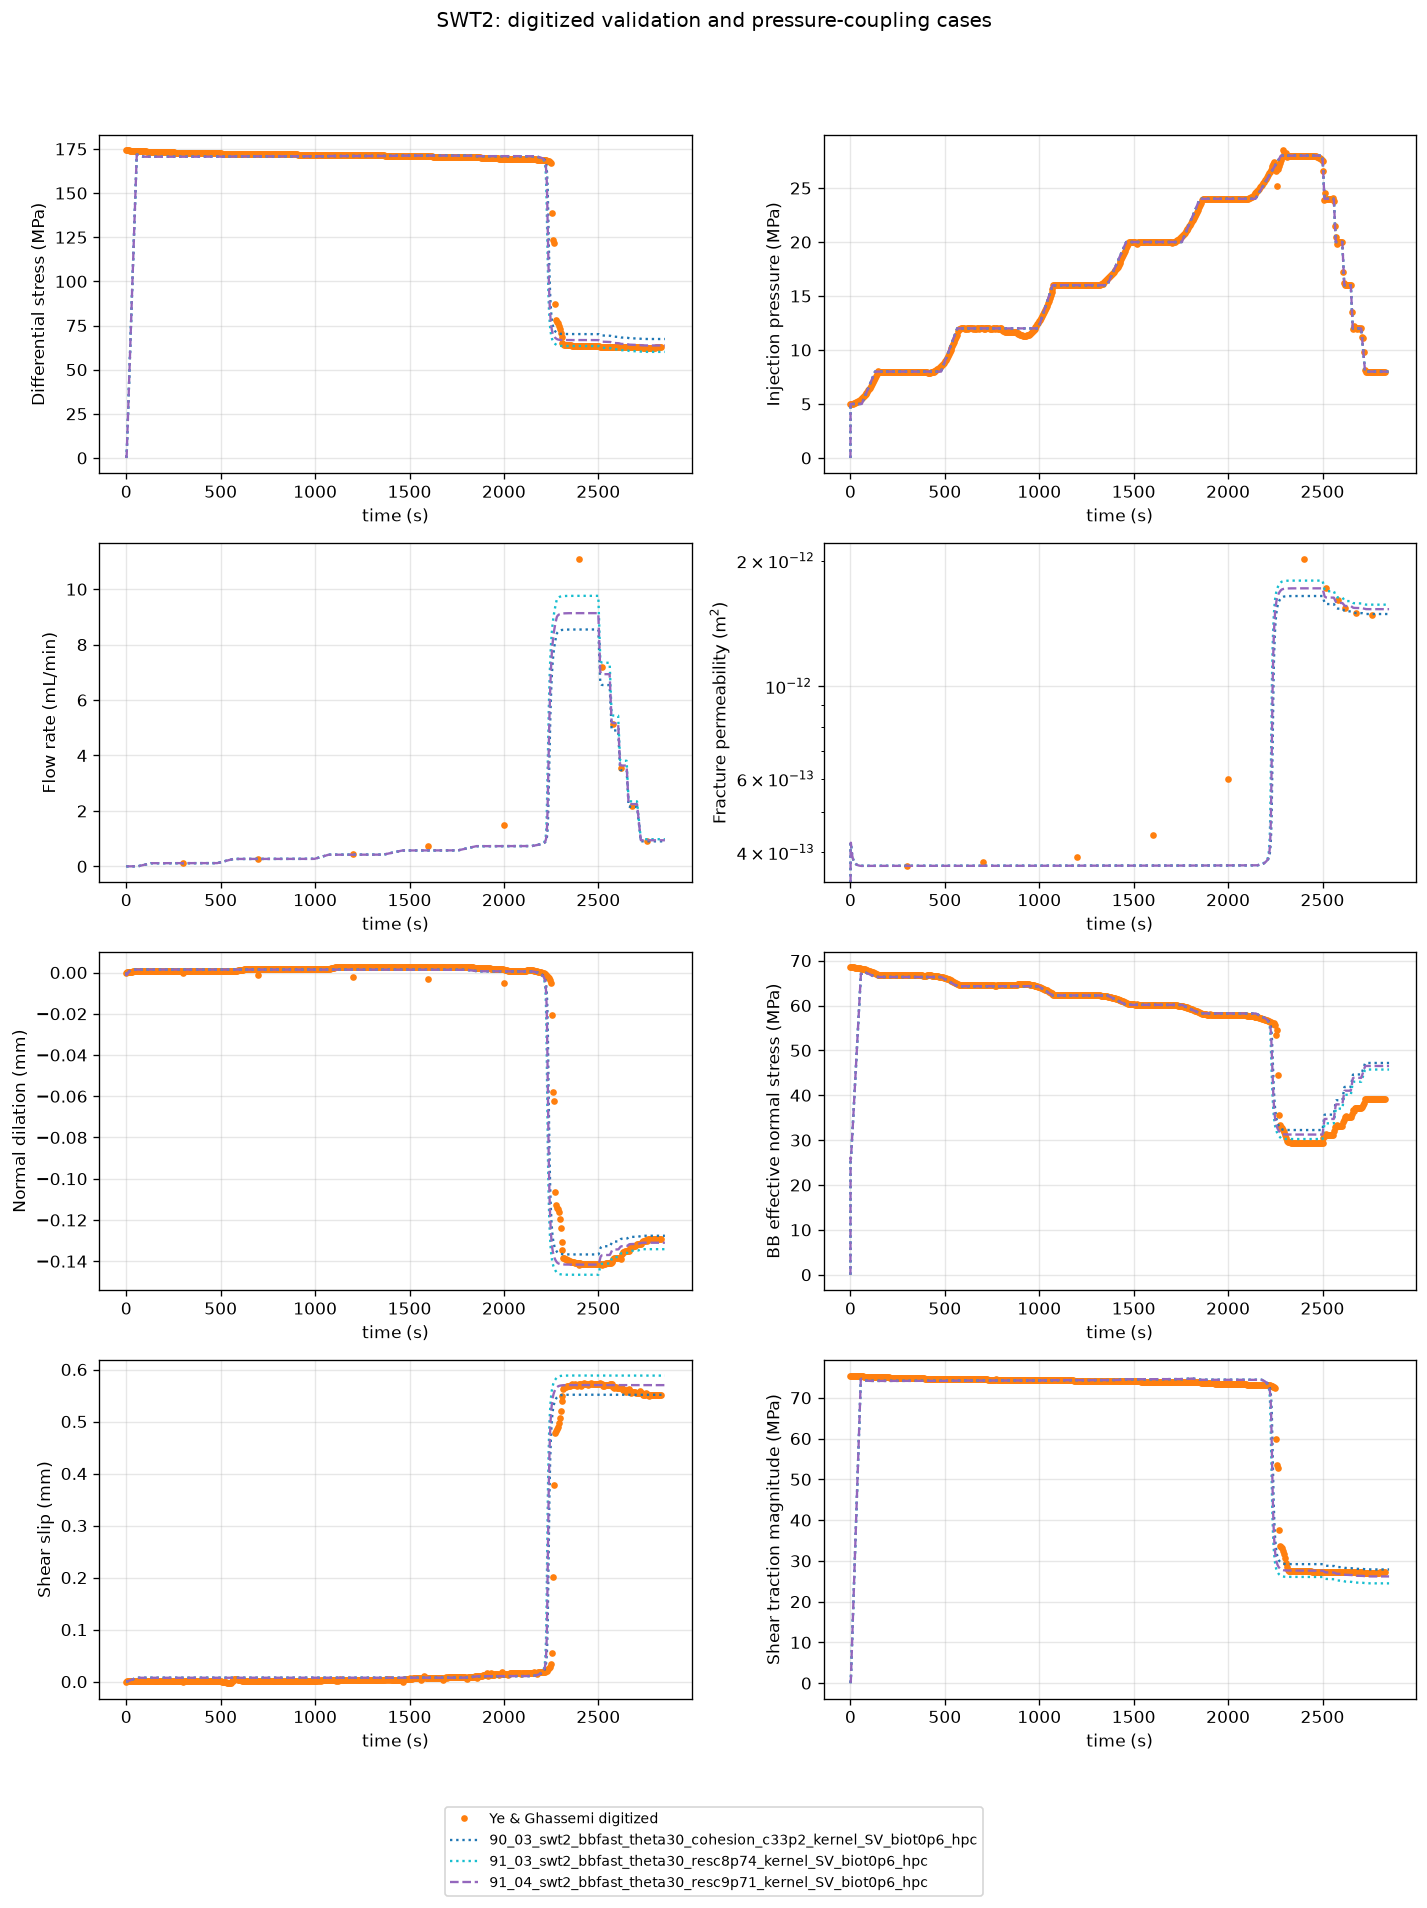

In [41]:
def get_series(data, alias, *, default=np.nan):
    series, column = first_series(data['df'], alias)
    if series is None:
        return pd.Series(default, index=data['df'].index), None
    return series, column


def plot_case_lines(ax, alias_or_column, *, scale=1.0, label_suffix='', allow_missing=True):
    plotted = False
    for name, data in loaded_cases.items():
        df = data['df']
        if alias_or_column in df.columns:
            y = pd.to_numeric(df[alias_or_column], errors='coerce') * scale
            source = alias_or_column
        else:
            y, source = first_series(df, alias_or_column)
            if y is not None:
                y = y * scale
        if y is None:
            if not allow_missing:
                print(f'{name}: missing {alias_or_column}')
            continue
        cfg = data['cfg']
        ax.plot(df['time'], y, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}{label_suffix}')
        plotted = True
    return plotted


def place_bottom_legend(fig, axes=None, *, ncol=None, bottom=0.12, top=0.98):
    if axes is None:
        axes = fig.axes
    axes = np.ravel(np.atleast_1d(axes)).tolist()

    legend_items = {}
    for ax in axes:
        existing_legend = ax.get_legend()
        if existing_legend is not None:
            existing_legend.remove()
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            if label and not label.startswith('_') and label not in legend_items:
                legend_items[label] = handle

    if legend_items:
        if ncol is None:
            ncol = min(4, len(legend_items))
        fig.legend(
            list(legend_items.values()),
            list(legend_items.keys()),
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=ncol,
            fontsize='small',
            frameon=True,
        )
    fig.tight_layout(rect=(0, bottom, 1, top))


def plot_metric(ax, metric, ylabel, *, yscale=None):
    plotted = plot_case_lines(ax, metric)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
    return plotted

# Paper-style validation comparison retained from the previous workflow, now for every loaded case.
panel_specs = [
    ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
    ('injection_pressure', 'injection_pressure_pa', 'Injection pressure (MPa)', 1.0e-6),
    ('flow_rate', 'flow_rate_ml_min', 'Flow rate (mL/min)'),
    ('frac_perm', 'fracture_permeability_m2', 'Fracture permeability (m$^2$)', 1.0, 'log'),
    ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
    ('normal_stress', 'bb_effective_normal_stress_pa', 'BB effective normal stress (MPa)', 1.0e-6),
    ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
    ('shear_stress', 'shear_traction_magnitude_pa', 'Shear traction magnitude (MPa)', 1.0e-6),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, spec in zip(axes.flat, panel_specs):
    key, alias, ylabel = spec[:3]
    scale = spec[3] if len(spec) > 3 else 1.0
    yscale = spec[4] if len(spec) > 4 else None
    v = validation.get(key)
    if v is not None and not v.empty:
        ax.plot(v['time_s'], v['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
    plot_case_lines(ax, alias, scale=scale)
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylabel)
    if yscale:
        ax.set_yscale(yscale)
fig.suptitle('SWT2: digitized validation and pressure-coupling cases', y=0.995)
place_bottom_legend(fig, axes, ncol=1, bottom=0.08, top=0.96)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_validation_comparison.png', bbox_inches='tight')
plt.show()

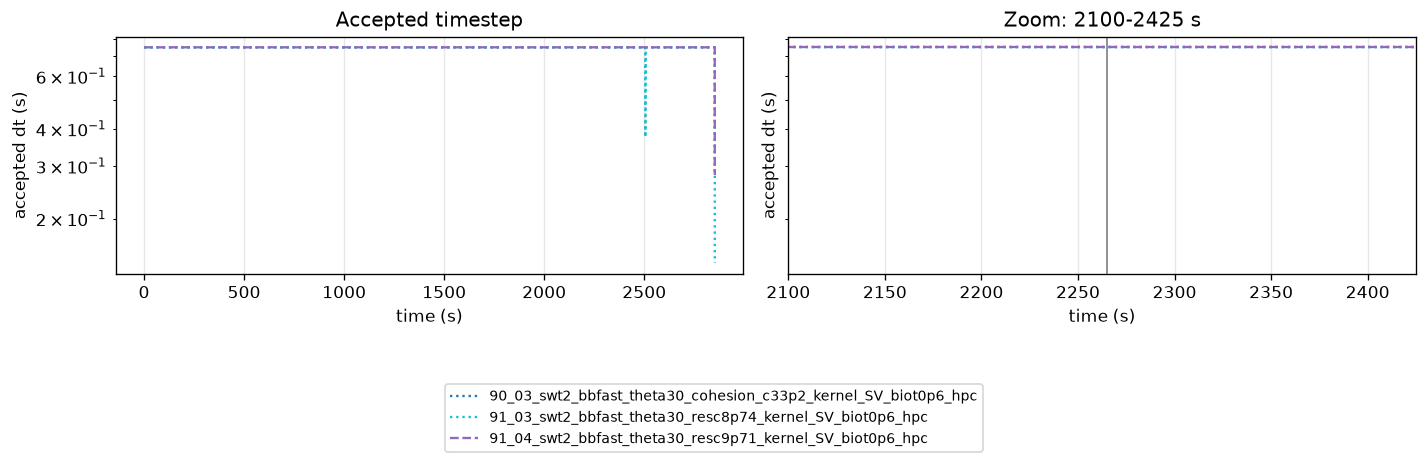

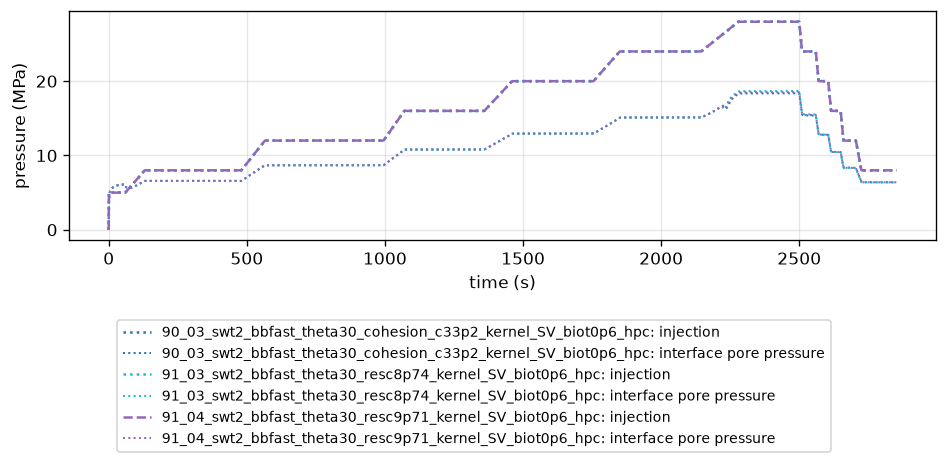

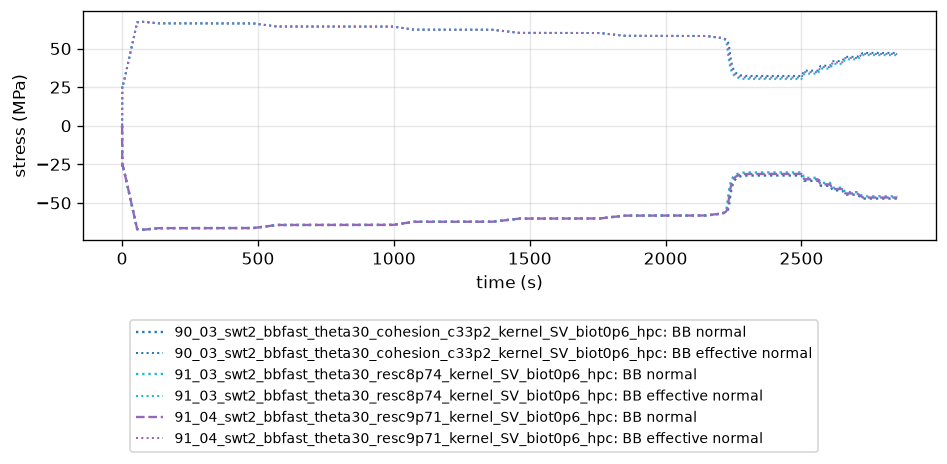

In [42]:
# 1. Accepted timestep versus time, with validation-event zoom.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_metric(axes[0], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
axes[0].set_title('Accepted timestep')
plot_metric(axes[1], 'accepted_dt_s', 'accepted dt (s)', yscale='log')
axes[1].set_xlim(*EVENT_WINDOW_S)
axes[1].axvline(EVENT_TIME_S, color='k', linewidth=1, alpha=0.5)
axes[1].set_title(f'Zoom: {EVENT_WINDOW_S[0]:g}-{EVENT_WINDOW_S[1]:g} s')
place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_dt.png', bbox_inches='tight')
plt.show()

# 2. Injection pressure and interface pore pressure.
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in loaded_cases.items():
    df = data['df']
    cfg = data['cfg']
    inj, inj_col = first_series(df, 'injection_pressure_pa')
    pif, pif_col = first_series(df, 'interface_pore_pressure_pa')
    if inj is not None:
        ax.plot(df['time'], inj / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.5, label=f'{name}: injection')
    if pif is not None:
        ax.plot(df['time'], pif / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: interface pore pressure')
ax.set_xlabel('time (s)')
ax.set_ylabel('pressure (MPa)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_pressures.png', bbox_inches='tight')
plt.show()

# 3. Contact normal stress and BB effective normal stress.
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in loaded_cases.items():
    df = data['df']
    cfg = data['cfg']
    normal, _ = first_series(df, 'bb_normal_stress_pa')
    effective, _ = first_series(df, 'bb_effective_normal_stress_pa')
    if normal is not None:
        ax.plot(df['time'], normal / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: BB normal')
    if effective is not None:
        ax.plot(df['time'], effective / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB effective normal')
ax.set_xlabel('time (s)')
ax.set_ylabel('stress (MPa)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_normal_stress.png', bbox_inches='tight')
plt.show()

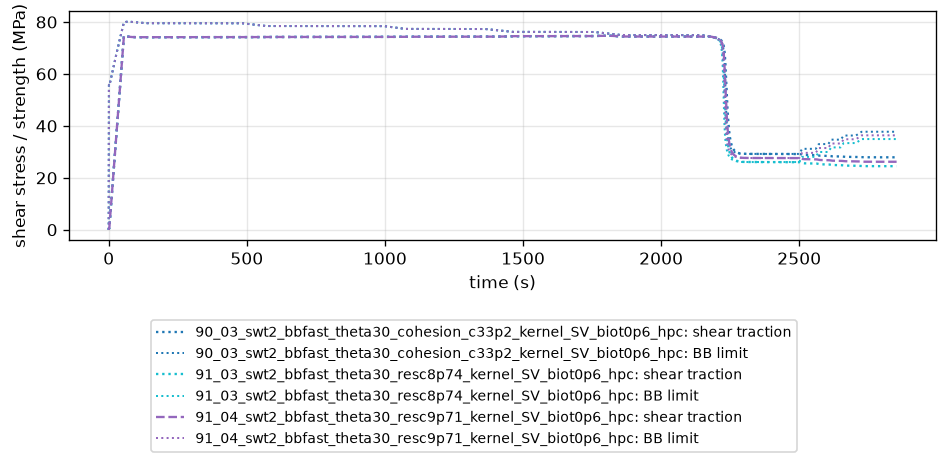

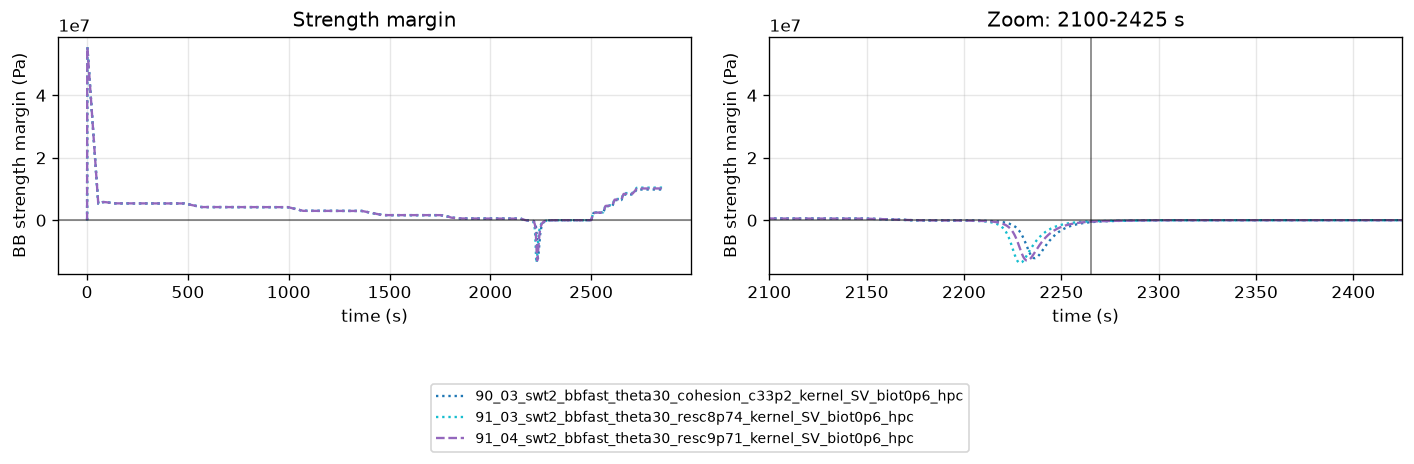

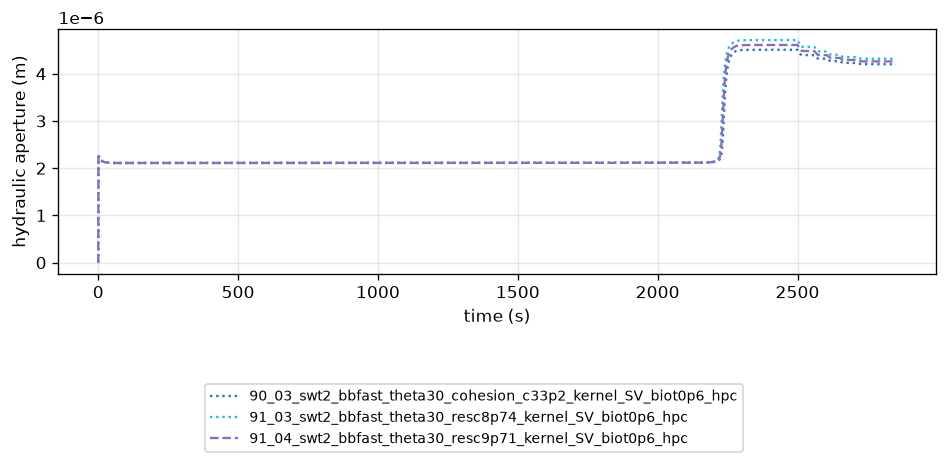

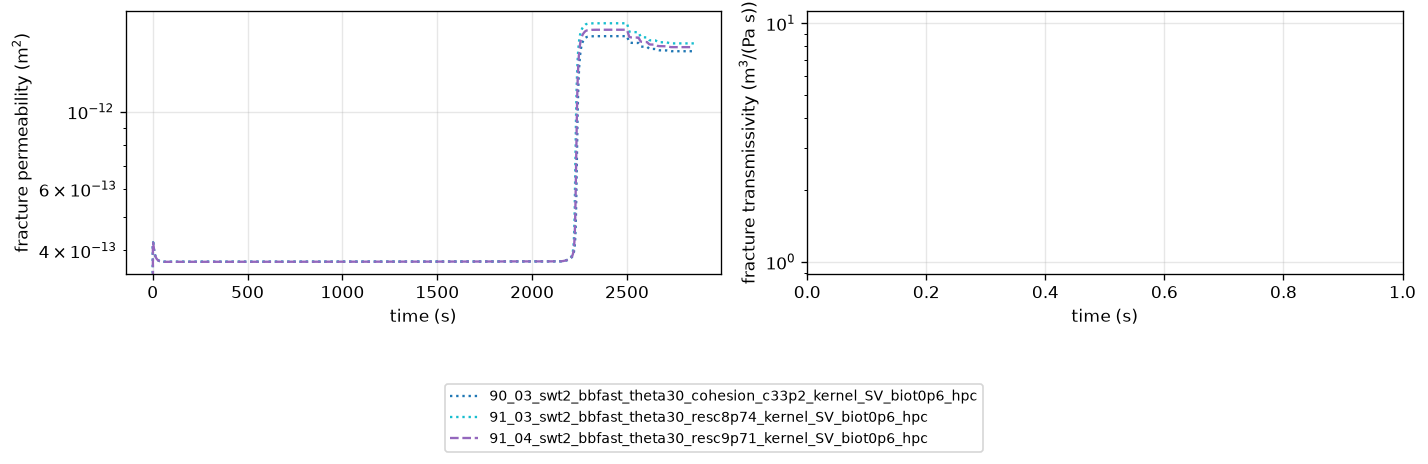

No nonlinear-iteration postprocessor column was available in the loaded CSV files.


In [43]:
# 4. Shear traction magnitude and BB shear-strength limit.
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in loaded_cases.items():
    df = data['df']
    cfg = data['cfg']
    shear = df.get('shear_traction_magnitude_pa')
    limit_tau, _ = first_series(df, 'bb_limit_tau_pa')
    if shear is not None:
        ax.plot(df['time'], shear / 1.0e6, linestyle=cfg['style'], color=cfg['color'], linewidth=1.4, label=f'{name}: shear traction')
    if limit_tau is not None:
        ax.plot(df['time'], limit_tau / 1.0e6, linestyle=':', color=cfg['color'], linewidth=1.2, label=f'{name}: BB limit')
ax.set_xlabel('time (s)')
ax.set_ylabel('shear stress / strength (MPa)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.32)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_shear_limit.png', bbox_inches='tight')
plt.show()

# 5. Shear-strength margin, with validation-event zoom.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
plot_metric(axes[0], 'strength_margin_pa', 'BB strength margin (Pa)')
axes[0].axhline(0.0, color='k', linewidth=1, alpha=0.5)
axes[0].set_title('Strength margin')
plot_metric(axes[1], 'strength_margin_pa', 'BB strength margin (Pa)')
axes[1].set_xlim(*EVENT_WINDOW_S)
axes[1].axhline(0.0, color='k', linewidth=1, alpha=0.5)
axes[1].axvline(EVENT_TIME_S, color='k', linewidth=1, alpha=0.5)
axes[1].set_title(f'Zoom: {EVENT_WINDOW_S[0]:g}-{EVENT_WINDOW_S[1]:g} s')
place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_strength_margin.png', bbox_inches='tight')
plt.show()

# 6. Hydraulic aperture.
fig, ax = plt.subplots(figsize=(8, 4))
plot_metric(ax, 'hydraulic_aperture_m', 'hydraulic aperture (m)')
place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_aperture.png', bbox_inches='tight')
plt.show()

# 7. Fracture permeability and transmissivity.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_metric(axes[0], 'fracture_permeability_m2', 'fracture permeability (m$^2$)', yscale='log')
plot_metric(axes[1], 'fracture_transmissivity_m3_pa_s', 'fracture transmissivity (m$^3$/(Pa s))', yscale='log')
place_bottom_legend(fig, axes, ncol=1, bottom=0.25)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_hydraulic_properties.png', bbox_inches='tight')
plt.show()

# 8. Nonlinear iterations or solver diagnostics, if available.
fig, ax = plt.subplots(figsize=(8, 4))
plotted_iterations = plot_metric(ax, 'nonlinear_iterations', 'nonlinear iterations')
if plotted_iterations:
    place_bottom_legend(fig, ax, ncol=1, bottom=0.25)
    fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_nonlinear_iterations.png', bbox_inches='tight')
    plt.show()
else:
    plt.close(fig)
    print('No nonlinear-iteration postprocessor column was available in the loaded CSV files.')

,case,quantity,n,rmse,mae,bias
0,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,differential_stress,567,1.704454e+01,4.733002e+00,-2.077297e+00
1,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,injection_pressure,567,3.383079e-01,1.598237e-01,3.763204e-02
2,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,flow_rate,11,8.336847e-01,4.117924e-01,-4.117924e-01
3,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,frac_perm,11,1.433475e-13,8.735250e-14,-8.556544e-14
4,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,normal_dilation,567,1.013685e-02,2.809808e-03,-7.303516e-04
5,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,normal_stress,567,5.431225e+00,1.924150e+00,1.710725e-01
6,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,shear_slip,567,3.920241e-02,1.061856e-02,4.867110e-03
7,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,shear_stress,567,7.346411e+00,1.845443e+00,-8.903873e-01
8,91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_b...,differential_stress,567,1.790463e+01,4.298545e+00,-3.806776e+00
9,91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_b...,injection_pressure,567,3.383120e-01,1.598058e-01,3.780884e-02


,case,validation_slip_onset_s,model_slip_onset_s,validation_dilation_onset_s,model_dilation_onset_s,validation_stress_drop_onset_s,model_stress_drop_onset_s
0,90_03_swt2_bbfast_theta30_cohesion_c33p2_kerne...,2100.0,2100.0,2215.0,2194.50,2100.0,2215.50
1,91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_b...,2100.0,2100.0,2215.0,2190.75,2100.0,2210.25
2,91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_b...,2100.0,2100.0,2215.0,2192.25,2100.0,2212.50


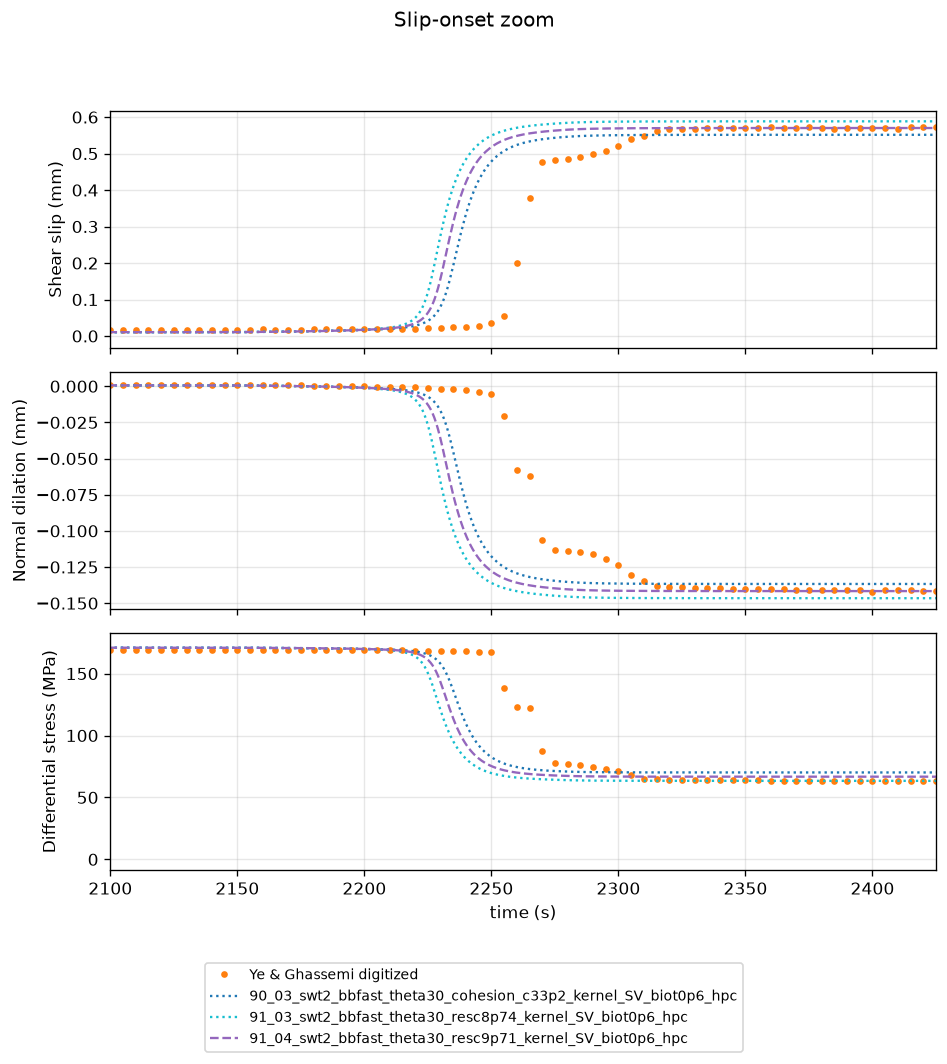

In [44]:
# Quantitative mismatch metrics and slip-onset zoom.
def interp_series(time, values, query_time):
    valid = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
    if valid.empty or query_time < valid['time'].iloc[0] or query_time > valid['time'].iloc[-1]:
        return np.nan
    return float(np.interp(query_time, valid['time'], valid['value']))

metric_specs = {
    'differential_stress': ('differential_stress_mpa', 1.0),
    'injection_pressure': ('injection_pressure_pa', 1.0e-6),
    'flow_rate': ('flow_rate_ml_min', 1.0),
    'frac_perm': ('fracture_permeability_m2', 1.0),
    'normal_dilation': ('normal_dilation_mm', 1.0),
    'normal_stress': ('bb_effective_normal_stress_pa', 1.0e-6),
    'shear_slip': ('shear_slip_mm', 1.0),
    'shear_stress': ('shear_traction_magnitude_pa', 1.0e-6),
}

metric_rows = []
for case_name, data in loaded_cases.items():
    df = data['df']
    for val_key, (alias, scale) in metric_specs.items():
        vdf = validation.get(val_key)
        if vdf is None or vdf.empty:
            continue
        if alias in df.columns:
            model_values = df[alias] * scale
        else:
            series, _ = first_series(df, alias)
            if series is None:
                continue
            model_values = series * scale
        errors = []
        for t_val, y_val in zip(vdf['time_s'], vdf['value']):
            y_model = interp_series(df['time'], model_values, t_val)
            if np.isfinite(y_model):
                errors.append(y_model - y_val)
        if errors:
            errors = np.asarray(errors, dtype=float)
            metric_rows.append({
                'case': case_name,
                'quantity': val_key,
                'n': int(len(errors)),
                'rmse': float(np.sqrt(np.mean(errors**2))),
                'mae': float(np.mean(np.abs(errors))),
                'bias': float(np.mean(errors)),
            })

metrics = pd.DataFrame(metric_rows)
with pd.option_context('display.max_rows', 200, 'display.max_columns', None):
    display(metrics)

def onset_time_from_xy(time, values, *, baseline_end=EVENT_BASELINE_END_S, threshold=0.002, direction='increase'):
    xy = pd.DataFrame({'time': time, 'value': values}).dropna().sort_values('time')
    early = xy.loc[xy['time'] <= baseline_end, 'value']
    baseline = float(early.median()) if not early.empty else float(xy['value'].iloc[0])
    for _, row in xy.loc[xy['time'] >= baseline_end].iterrows():
        delta = row['value'] - baseline
        if direction == 'increase' and delta >= threshold:
            return float(row['time'])
        if direction == 'decrease' and -delta >= threshold:
            return float(row['time'])
    return np.nan

onset_rows = []
val_slip_onset = onset_time_from_xy(validation['shear_slip']['time_s'], validation['shear_slip']['value'], threshold=0.002, direction='increase')
val_dilation_onset = onset_time_from_xy(validation['normal_dilation']['time_s'], validation['normal_dilation']['value'], threshold=0.002, direction='decrease')
val_stress_drop_onset = onset_time_from_xy(validation['differential_stress']['time_s'], validation['differential_stress']['value'], threshold=2.0, direction='decrease')
for case_name, data in loaded_cases.items():
    df = data['df']
    slip, _ = first_series(df, 'shear_slip_mm')
    dilation, _ = first_series(df, 'normal_dilation_mm')
    diff, _ = first_series(df, 'differential_stress_mpa')
    onset_rows.append({
        'case': case_name,
        'validation_slip_onset_s': val_slip_onset,
        'model_slip_onset_s': onset_time_from_xy(df['time'], slip, threshold=0.002, direction='increase') if slip is not None else np.nan,
        'validation_dilation_onset_s': val_dilation_onset,
        'model_dilation_onset_s': onset_time_from_xy(df['time'], dilation, threshold=0.002, direction='decrease') if dilation is not None else np.nan,
        'validation_stress_drop_onset_s': val_stress_drop_onset,
        'model_stress_drop_onset_s': onset_time_from_xy(df['time'], diff, threshold=2.0, direction='decrease') if diff is not None else np.nan,
    })
onsets = pd.DataFrame(onset_rows)
display(onsets)

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
zoom = EVENT_WINDOW_S
plot_items = [
    ('shear_slip', 'shear_slip_mm', 'Shear slip (mm)'),
    ('normal_dilation', 'normal_dilation_mm', 'Normal dilation (mm)'),
    ('differential_stress', 'differential_stress_mpa', 'Differential stress (MPa)'),
]
for ax, (val_key, alias, ylabel) in zip(axes, plot_items):
    vdf = validation[val_key]
    ax.plot(vdf['time_s'], vdf['value'], 'o', ms=3, color='tab:orange', label='Ye & Ghassemi digitized')
    plot_case_lines(ax, alias)
    ax.set_xlim(*zoom)
    ax.set_ylabel(ylabel)
axes[-1].set_xlabel('time (s)')
fig.suptitle('Slip-onset zoom')
place_bottom_legend(fig, axes, ncol=1, bottom=0.12, top=0.94)
fig.savefig(BASE / 'Ye2018_SWT2_pressure_coupling_slip_onset_zoom.png', bbox_inches='tight')
plt.show()

In [45]:
print(f'{SAMPLE} validation coverage')
print('-' * (len(SAMPLE) + 20))
print(f'Validation data extend to {VALIDATION_END_TIME_S:.3f} s.')
print(f'Major measured transition is assessed over {EVENT_WINDOW_S[0]:.1f}-{EVENT_WINDOW_S[1]:.1f} s.')
for row in summary.to_dict('records'):
    status = 'complete' if row['reached_validation_end'] else 'partial'
    print(
        f"{row['case']}: {status} validation coverage "
        f"(simulation {row['final_time_s']:.3f} s; validation criterion {VALIDATION_END_TIME_S:.3f} s)."
    )


SWT2 validation coverage
------------------------
Validation data extend to 2830.000 s.
Major measured transition is assessed over 2100.0-2425.0 s.
90_03_swt2_bbfast_theta30_cohesion_c33p2_kernel_SV_biot0p6_hpc: complete validation coverage (simulation 2852.530 s; validation criterion 2830.000 s).
91_03_swt2_bbfast_theta30_resc8p74_kernel_SV_biot0p6_hpc: complete validation coverage (simulation 2852.530 s; validation criterion 2830.000 s).
91_04_swt2_bbfast_theta30_resc9p71_kernel_SV_biot0p6_hpc: complete validation coverage (simulation 2852.530 s; validation criterion 2830.000 s).


## Reproducibility notes

Run this notebook from the `SWT2` directory. It reads digitized validation data
from `SWT2/`, simulation time histories from `results_csv/`, and matching input
decks from the current directory. Result CSV files without a `time` column (for
example, Table-2 summaries) are intentionally excluded from the time-history plots.
